# Data Management – GreenGarten Versandhandel GmbH

Explorative Bereinigung von `data/raw/verkaufe.csv` (Verkaufsdaten von
600 Produkten über 24 Monate). Ziel dieses Notebooks: die Rohdaten Schritt
für Schritt verstehen, alle Format- und Datenqualitätsprobleme
identifizieren und zu `df_verkaufe_clean` bereinigen – jeder Schritt wird
begründet und am tatsächlichen Ergebnis überprüft, bevor der nächste
folgt. `verkaufe.csv` wird dabei nur gelesen, nie verändert.

**Agenda:**

1. **Rohdaten laden** – einlesen und erster visueller Eindruck.
2. **Statistik-Check** – Datentypen, Wertebereiche und fehlende Werte
   vollständig erfassen, bevor irgendetwas verändert wird.
3. **Data Cleaning** – Duplikate, Schreibweisen, Datums- und
   Preisformate sowie die Logik hinter strukturell fehlenden Werten.
4. **Ausreißer suchen** – `umsatz_eur` auf unplausible Werte prüfen und
   über eine Kreuzvalidierung exakt korrigieren.
5. **Verbleibende Spalten bereinigen** – `lagerbestand`,
   `bewertungen_durchschnitt` und `marketingbudget_eur`.
6. **Abschluss** – finale Spaltenreihenfolge, CSV-Export und
   Zusammenfassung aller gefundenen Datenfehler.

## 1 Rohdaten laden

### 1.1 Bibliotheken importieren

`pandas`/`numpy` für die eigentliche Datenverarbeitung, `matplotlib`/
`seaborn` für spätere Visualisierungen (z. B. Missing-Data-Heatmap).

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### 1.2 Rohdaten einlesen

`verkaufe.csv` wird ausschließlich eingelesen – an keiner Stelle in
diesem Notebook wird auf diese Datei geschrieben.

In [2]:
path = "../data/raw/verkaufe.csv"
df_verkaufe_raw = pd.read_csv(path)
df_verkaufe_raw.shape

(14430, 16)

**Ergebnis:** 14.430 Zeilen, 16 Spalten. Erwartet wären 600 Produkte
× 24 Monate = 14.400 Zeilen – die 30 zusätzlichen Zeilen sind ein erster
Hinweis auf Duplikate, der in Abschnitt 2.4 überprüft wird.

### 1.3 Erste Übersicht

In [3]:
df_verkaufe_raw.head()

,produkt_id,kategorie,hersteller,monat,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_anzahl,vormonat_umsatz_eur,letzte_3_monate_umsatz_eur_avg,vorjahr_monat_umsatz_eur,umsatz_eur
0,PR-0000,Saatgut,Hortica,01.2024,1,"1,50 €",1.41,89.61,0,67,3.70,39,NaN,NaN,NaN,6.12
1,PR-0000,Saatgut,Hortica,2024-02,2,1.5,1.69,88.16,1,69,3.70,39,6.12,6.12,NaN,13.64
2,PR-0000,Saatgut,Hortica,2024-03,3,1.5,1.61,117.38,1,64,3.70,39,13.64,9.88,NaN,16.75
3,PR-0000,Saatgut,Hortica,04.2024,4,1.5,1.40,99.85,0,72,3.70,39,16.75,12.17,NaN,22.68
4,PR-0000,Saatgut,Hortica,05/2024,5,1.5,1.45,101.72,0,35,3.70,39,22.68,17.69,NaN,11.98


**Erste Beobachtung:** Schon in diesen 5 Zeilen (alle vom selben
Produkt `PR-0000`, Monate 1–5) zeigen sich zwei Formatprobleme sehr
deutlich: `monat` wechselt zwischen `01.2024`, `2024-02`, `2024-03`,
`04.2024` und `05/2024` – drei verschiedene Schreibweisen für dieselbe
Art von Wert. `preis_eur` wechselt zwischen `"1,50 €"` (Text mit
Euro-Zeichen und Komma) und `1.5` (reine Zahl), obwohl der Preis pro
Produkt eigentlich konstant sein sollte.

## 2 Statistik-Check

Bevor irgendetwas bereinigt wird, verschafft dieser Abschnitt einen vollständigen Überblick über Spalten, Datentypen, Wertebereiche und fehlende Werte – Grundlage für alle folgenden Entscheidungen.

### 2.1 Table Information

Ziel: auf einen Blick sehen, welchen Datentyp jede Spalte aktuell hat
und wie viele Werte pro Spalte tatsächlich befüllt sind.

In [4]:
df_verkaufe_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 14430 entries, 0 to 14429
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   produkt_id                      14430 non-null  str    
 1   kategorie                       14430 non-null  str    
 2   hersteller                      14430 non-null  str    
 3   monat                           14430 non-null  str    
 4   monat_idx                       14430 non-null  int64  
 5   preis_eur                       14430 non-null  str    
 6   wettbewerber_preis_eur          14430 non-null  float64
 7   marketingbudget_eur             13997 non-null  float64
 8   kampagne_aktiv                  14430 non-null  int64  
 9   lagerbestand                    14430 non-null  str    
 10  bewertungen_durchschnitt        13854 non-null  float64
 11  bewertungen_anzahl              14430 non-null  int64  
 12  vormonat_umsatz_eur             13828 non-n

**Ergebnis:** 16 Spalten, davon drei mit dem Typ `str` (Text),
obwohl sie inhaltlich numerisch bzw. ein Datum sind: `monat`, `preis_eur`
und `lagerbestand`. Das bestätigt die Formatprobleme aus 1.3 – bevor mit
diesen Spalten gerechnet werden kann, müssen sie in echte Zahlen-/
Datums-Typen umgewandelt werden. Nicht-vollständig befüllt sind laut
`Non-Null Count` u. a. `marketingbudget_eur`, `bewertungen_durchschnitt`,
`vormonat_umsatz_eur`, `letzte_3_monate_umsatz_eur_avg` und
`vorjahr_monat_umsatz_eur` – Details dazu in 2.3.

### 2.2 Statistical Exploration

Ziel: Wertebereiche (Min/Max/Mittelwert) je Spalte prüfen, um
unplausible Ausreißer und fehlende Werte frühzeitig zu erkennen –
zunächst die numerischen Spalten.

In [5]:
df_verkaufe_raw.describe(include=['float', 'int']).T

,count,mean,std,min,25%,50%,75%,max
monat_idx,14430.00,6.50,3.45,1.00,3.25,7.00,9.00,12.00
wettbewerber_preis_eur,14430.00,26.17,23.53,1.28,8.01,20.33,34.86,164.70
marketingbudget_eur,13997.00,89.71,30.10,0.00,69.10,88.09,108.83,236.79
kampagne_aktiv,14430.00,0.11,0.32,0.00,0.00,0.00,0.00,1.00
bewertungen_durchschnitt,13854.00,3.51,0.69,1.50,3.00,3.50,4.00,5.00
bewertungen_anzahl,14430.00,40.20,6.09,24.00,36.00,40.00,44.00,59.00
vormonat_umsatz_eur,13828.00,526.50,962.26,1.71,71.61,207.49,579.15,20617.85
letzte_3_monate_umsatz_eur_avg,14429.00,517.94,899.40,1.96,76.80,214.65,580.63,16162.51
vorjahr_monat_umsatz_eur,7210.00,514.78,941.20,1.82,69.34,204.81,565.96,20617.85
umsatz_eur,14430.00,638.18,10442.64,-150.00,70.25,202.89,567.87,999999.00


**Auffälligkeiten in der numerischen Übersicht:**

- `umsatz_eur`: Minimum `-150,00 €`, Maximum `999.999,00 €`. Ein
  negativer Umsatz ist fachlich nicht möglich, und `999.999` liegt
  weit außerhalb der sonstigen Größenordnung (Mittelwert `638 €`,
  Median `≈ 203 €`) – klassische Platzhalter-/Erfassungsfehler.
  Std-Abweichung (`10.442`) ist dadurch selbst stark verzerrt.
- `vormonat_umsatz_eur` (13.828), `letzte_3_monate_umsatz_eur_avg`
  (14.429) und `vorjahr_monat_umsatz_eur` (7.210) haben spürbar
  niedrigere `count`-Werte als die 14.430 Zeilen insgesamt – das sind
  die bereits in 2.1 gesehenen fehlenden Werte.
- `marketingbudget_eur` (13.997) und `bewertungen_durchschnitt`
  (13.854) ebenso.
- `wettbewerber_preis_eur`, `kampagne_aktiv`, `bewertungen_anzahl` und
  `monat_idx` sind vollständig befüllt und wirken auf den ersten Blick
  plausibel.

Anschließend dieselbe Übersicht für die kategorischen/Text-Spalten – vor allem die Anzahl eindeutiger Werte (`unique`) verrät, wo mehr Ausprägungen vorkommen als fachlich möglich sein sollten.

In [6]:
df_verkaufe_raw.describe(include=['object']).T

,count,unique,top,freq
produkt_id,14430,600,PR-0191,26
kategorie,14430,24,Pflanzen,4218
hersteller,14430,6,Vivero,2672
monat,14430,72,11.2024,226
preis_eur,14430,909,1.5,512
lagerbestand,14430,389,47,172


**Auffälligkeiten in der kategorischen Übersicht:**

- `produkt_id`: 600 eindeutige Werte – passt zur erwarteten Produktzahl.
- `kategorie`: **24** eindeutige Werte, obwohl fachlich nur 6 Kategorien
  existieren (Pflanzen, Werkzeuge, Saatgut, Toepfe, Duengemittel,
  Bewaesserung) – Schreibweisen-Varianten (Groß-/Kleinschreibung,
  Umlaute, Abkürzungen wie `DUENGER`/`Saat`).
- `hersteller`: 6 eindeutige Werte – sauber, kein Bereinigungsbedarf.
- `monat`: **72** eindeutige Werte statt der erwarteten 24 (2 Jahre ×
  12 Monate) – exakt das Dreifache, passend zu den 3 Datumsformaten aus
  1.3.
- `preis_eur`: **909** eindeutige Werte – ungewöhnlich viele für eine
  Spalte, die pro Produkt konstant sein sollte; auch hier ein Hinweis
  auf die gemischten Text-/Zahl-Formate.
- `lagerbestand`: 389 eindeutige Werte, als Text gespeichert (siehe 2.1).

### 2.3 Fehlende Werte je Spalte

Ziel: pro Spalte zählen, wie viele Werte tatsächlich fehlen – als
Grundlage, um im nächsten Schritt zu unterscheiden, welche Lücken
strukturell erklärbar sind und welche echte Datenfehler sind.

In [7]:
df_verkaufe_raw.isna().sum()

,0
produkt_id,0
kategorie,0
hersteller,0
monat,0
monat_idx,0
preis_eur,0
wettbewerber_preis_eur,0
marketingbudget_eur,433
kampagne_aktiv,0
lagerbestand,0


**Einordnung der fehlenden Werte** (wird in der Bereinigung weiter
unten im Detail behandelt):

- `marketingbudget_eur` (433) und `bewertungen_durchschnitt` (576) ohne
  erkennbares Muster – vermutlich echte Datenlücken.
- `vormonat_umsatz_eur` (602) und `vorjahr_monat_umsatz_eur` (7.220)
  strukturell erklärbar: für den 1. Verkaufsmonat eines Produkts gibt es
  keinen Vormonat, für das 1. Jahr des Datensatzes (2024) kein Vorjahr.
- `letzte_3_monate_umsatz_eur_avg` fehlt dagegen nur in **einer**
  einzigen Zeile – auffällig wenig für eine Spalte, die laut Definition
  ("Durchschnitt der letzten 3 Monate") erst ab dem 4. Verkaufsmonat
  eines Produkts überhaupt einen Wert haben kann. Das deutet auf einen
  eigenen Datenqualitätsfehler hin, der separat untersucht werden muss.
- `umsatz_eur` selbst hat 0 fehlende Werte – die in 2.2 gefundenen
  Ausreißer (`-150`, `999.999`) stecken also als **Werte**, nicht als
  `NaN`, in der Spalte.

Welche Spalten haben überhaupt fehlende Werte (als Boolean-Maske)?

In [8]:
spalten_mit_nan = df_verkaufe_raw.isna().sum() > 0
spalten_mit_nan

,0
produkt_id,False
kategorie,False
hersteller,False
monat,False
monat_idx,False
preis_eur,False
wettbewerber_preis_eur,False
marketingbudget_eur,True
kampagne_aktiv,False
lagerbestand,False


Nützlich, um weiter unten gezielt nur die betroffenen Spalten zu
filtern (z. B. für eine Missing-Data-Heatmap), ohne die Zahlen aus der
vorherigen Zelle erneut abzutippen.

### 2.4 Eindeutige Werte je Spalte (Stichprobe)

In [9]:
for col in df_verkaufe_raw.columns:
    print(f"\nSpalte: {col}")
    print(df_verkaufe_raw[col].unique()[:20])


Spalte: produkt_id
<StringArray>
['PR-0000', 'PR-0001', 'PR-0002', 'PR-0003', 'PR-0004', 'PR-0005', 'PR-0006',
 'PR-0007', 'PR-0008', 'PR-0009', 'PR-0010', 'PR-0011', 'PR-0012', 'PR-0013',
 'PR-0014', 'PR-0015', 'PR-0016', 'PR-0017', 'PR-0018', 'PR-0019']
Length: 20, dtype: str

Spalte: kategorie
<StringArray>
[     'Saatgut', 'Bewaesserung', 'bewaesserung', 'Duengemittel',
      'DUENGER',    'Werkzeuge',     'Pflanzen',      'Pflanze',
     'PFLANZEN',       'Toepfe',  'Düngemittel', 'BEWAESSERUNG',
      'saatgut',      'SAATGUT',     'pflanzen',       'toepfe',
 'duengemittel',         'Saat',    'werkzeuge',    'WERKZEUGE']
Length: 20, dtype: str

Spalte: hersteller
<StringArray>
['Hortica', 'GartenStern', 'BioGruen', 'Vivero', 'Floraplan', 'Garda Tools']
Length: 6, dtype: str

Spalte: monat
<StringArray>
['01.2024', '2024-02', '2024-03', '04.2024', '05/2024', '2024-06', '2024-07',
 '2024-08', '09.2024', '2024-10', '11.2024', '12.2024', '01.2025', '2025-02',
 '03.2025', '04/2025'

**Bestätigt und konkretisiert die bisherigen Vermutungen:**

- `kategorie`: in der Stichprobe bereits `'Saatgut'`, `'saatgut'`,
  `'SAATGUT'`, `'Saat'`, `'Bewaesserung'`, `'bewaesserung'`,
  `'BEWAESSERUNG'`, `'Pflanzen'`, `'Pflanze'`, `'PFLANZEN'` etc.
  sichtbar – Groß-/Kleinschreibung, Umlaut-Varianten und Abkürzungen
  gemischt.
- `monat`: `'01.2024'`, `'2024-02'`, `'2024-03'`, `'04.2024'`,
  `'05/2024'` – alle drei Formate (`MM.YYYY`, `YYYY-MM`, `MM/YYYY`)
  treten nebeneinander auf.
- `preis_eur`: `'1,50 €'` neben `'1.5'`, `'102.04'` – Text-mit-Euro-Komma
  und reine Zahl gemischt.
- `lagerbestand`: in der 20er-Stichprobe wirken die Werte rein
  numerisch (`'67'`, `'69'`, ...), aber als `str` gespeichert (siehe
  2.1). Eine gezielte Prüfung zeigt, dass ein Teil der Zeilen zusätzlich
  einen Text-Zusatz trägt:

In [10]:
lagerbestand_mit_text = df_verkaufe_raw["lagerbestand"].astype(str).str.contains("[A-Za-z]")
print(f"Zeilen mit Text-Zusatz in 'lagerbestand': {lagerbestand_mit_text.sum()} von {len(df_verkaufe_raw)}")
df_verkaufe_raw.loc[lagerbestand_mit_text, "lagerbestand"].unique()[:5]

Zeilen mit Text-Zusatz in 'lagerbestand': 288 von 14430


<StringArray>
['91 Stueck', '45 Stueck', '154 Stueck', '36 Stueck', '50 Stueck']
Length: 5, dtype: str

→ Werte wie `'91 Stueck'` statt `91` – in der 20er-Stichprobe oben
nicht sichtbar, weil diese Zeilen dort nicht unter den ersten 20 lagen,
aber klar vorhanden (288 Zeilen betroffen).

**Und die 30 zusätzlichen Zeilen aus 1.2?**

In [11]:
anzahl_duplikate = df_verkaufe_raw.duplicated().sum()
print(f"Vollstaendige Duplikate (alle Spalten identisch): {anzahl_duplikate}")

Vollstaendige Duplikate (alle Spalten identisch): 30


→ Bestätigt: 30 vollständige Duplikate, exakt die Differenz
zwischen den 14.430 Rohzeilen und den erwarteten 14.400 (600 Produkte ×
24 Monate).

## 3 Data Cleaning

### 3.1 `df_verkaufe_clean` anlegen

Ab hier wird nur noch mit einer Kopie gearbeitet – `df_verkaufe_raw`
bleibt unverändert als Referenz auf die Rohdaten erhalten.

In [12]:
df_verkaufe_clean = df_verkaufe_raw.copy()
df_verkaufe_clean.shape

(14430, 16)

Noch identisch zu den Rohdaten (14.430 Zeilen × 16 Spalten) – die
eigentliche Bereinigung (Formate, Duplikate, fehlende Werte, Ausreißer)
folgt in den nächsten Schritten.

### 3.2 Duplikate entfernen

Duplikate werden zuerst gesucht und gezählt, bevor überhaupt etwas
gelöscht wird – damit nachvollziehbar bleibt, wie viele Zeilen betroffen
sind und ob es sich wirklich um vollständige, exakte Duplikate handelt
(nicht nur gleiche `produkt_id` + `monat`).

**Suchen:** Welche Zeilen sind (inkl. ihres jeweiligen Originals) an einem Duplikat beteiligt?

In [13]:
duplikat_zeilen = df_verkaufe_clean[df_verkaufe_clean.duplicated(keep=False)]
duplikat_zeilen.sort_values(["produkt_id", "monat"]).head(10)

,produkt_id,kategorie,hersteller,monat,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_anzahl,vormonat_umsatz_eur,letzte_3_monate_umsatz_eur_avg,vorjahr_monat_umsatz_eur,umsatz_eur
439,PR-0018,Saatgut,Hortica,2024-08,8,7.26,7.26,65.98,0,56,3.30,39,63.81,83.33,NaN,40.60
14417,PR-0018,Saatgut,Hortica,2024-08,8,7.26,7.26,65.98,0,56,3.30,39,63.81,83.33,NaN,40.60
766,PR-0031,Pflanzen,Floraplan,11/2025,11,36.52,37.49,70.92,0,46,3.00,41,221.99,264.50,100.49,128.35
14402,PR-0031,Pflanzen,Floraplan,11/2025,11,36.52,37.49,70.92,0,46,3.00,41,221.99,264.50,100.49,128.35
2622,PR-0109,Pflanzen,Floraplan,2024-07,7,32.58,32.48,70.36,0,79,2.70,47,1386.48,1161.61,NaN,628.68
14420,PR-0109,Pflanzen,Floraplan,2024-07,7,32.58,32.48,70.36,0,79,2.70,47,1386.48,1161.61,NaN,628.68
2812,PR-0117,Pflanzen,BioGruen,2024-05,5,14.0,15.65,140.16,0,101,4.50,42,250.60,167.65,NaN,294.72
14425,PR-0117,Pflanzen,BioGruen,2024-05,5,14.0,15.65,140.16,0,101,4.50,42,250.60,167.65,NaN,294.72
3342,PR-0139,Bewaesserung,Garda Tools,2024-07,7,76.3,80.84,132.16,0,13,4.00,32,2670.84,1383.85,NaN,2560.08
14401,PR-0139,Bewaesserung,Garda Tools,2024-07,7,76.3,80.84,132.16,0,13,4.00,32,2670.84,1383.85,NaN,2560.08


**Zählen:** Wie viele Zeilen sind reine Wiederholungen (Original bereits vorhanden)?

In [14]:
anzahl_duplikate = df_verkaufe_clean.duplicated().sum()
print(f"Vollstaendige Duplikate (zu loeschende Zeilen): {anzahl_duplikate}")
print(f"Davon betroffene Zeilen insgesamt (Original + Kopie): {len(duplikat_zeilen)}")

Vollstaendige Duplikate (zu loeschende Zeilen): 30
Davon betroffene Zeilen insgesamt (Original + Kopie): 60


**Ergebnis:** 30 Zeilen sind reine Wiederholungen einer bereits
vorhandenen Zeile (60 Zeilen insgesamt an Duplikaten beteiligt, je
Original + Kopie) – exakt die Differenz zwischen den 14.430 Rohzeilen
und den erwarteten 14.400.

**Löschen:** `drop_duplicates()` behält jeweils die erste Vorkommnis und entfernt nur die überzähligen Kopien.

In [15]:
vorher = len(df_verkaufe_clean)
df_verkaufe_clean = df_verkaufe_clean.drop_duplicates()
nachher = len(df_verkaufe_clean)

print(f"Zeilen vorher: {vorher}")
print(f"Zeilen nachher: {nachher}")
print(f"Entfernt: {vorher - nachher}")
print(f"Erwartet: 600 Produkte x 24 Monate = 14.400 -> {'passt' if nachher == 14_400 else 'passt NICHT'}")

Zeilen vorher: 14430
Zeilen nachher: 14400
Entfernt: 30
Erwartet: 600 Produkte x 24 Monate = 14.400 -> passt


**Ergebnis:** 30 Zeilen entfernt, 14.400 verbleiben – passt exakt
zur erwarteten Anzahl (600 Produkte × 24 Monate).

### 3.3 `kategorie`: einheitliche Schreibweise

Gleiches Vorgehen wie bei den Duplikaten: zuerst suchen/zählen, was an
Schreibweisen überhaupt vorkommt, dann gezielt vereinheitlichen.

**Suchen & zählen:** alle vorkommenden Schreibweisen mit Häufigkeit.

In [16]:
df_verkaufe_clean["kategorie"].value_counts()

,count
kategorie,
Pflanzen,4207
Werkzeuge,2669
Saatgut,2490
Toepfe,1808
Duengemittel,1526
Bewaesserung,1268
PFLANZEN,47
pflanzen,46
Pflanze,44


**Ergebnis:** 24 unterschiedliche Schreibweisen für nur 6 fachliche
Kategorien – Groß-/Kleinschreibung, Umlaut-Varianten (`ae`/`ä`) und
Abkürzungen (`Saat`/`Saatgut`, `Duenger`/`Duengemittel`) gemischt.

**Bereinigen:** Jeder Wert wird zunächst normalisiert (getrimmt,
kleingeschrieben, Umlaute in `ae`/`oe`/`ue`/`ss` übersetzt) und
anschließend über eine feste Zuordnung auf eine der 6 echten Kategorien
gemappt.

In [17]:
KATEGORIE_MAPPING = {
    "pflanzen": "Pflanzen", "pflanze": "Pflanzen",
    "werkzeuge": "Werkzeuge", "werkzeug": "Werkzeuge",
    "saatgut": "Saatgut", "saat": "Saatgut",
    "toepfe": "Toepfe",
    "duengemittel": "Duengemittel", "duenger": "Duengemittel",
    "bewaesserung": "Bewaesserung",
}


def kategorie_normalisieren(wert):
    text = str(wert).strip().lower()
    text = (text.replace("ä", "ae").replace("ö", "oe")
                .replace("ü", "ue").replace("ß", "ss"))
    return text


df_verkaufe_clean["kategorie"] = (
    df_verkaufe_clean["kategorie"].apply(kategorie_normalisieren).map(KATEGORIE_MAPPING)
)
df_verkaufe_clean["kategorie"].value_counts()

,count
kategorie,
Pflanzen,4344
Werkzeuge,2760
Saatgut,2568
Toepfe,1848
Duengemittel,1560
Bewaesserung,1320


**Kontrolle:** genau 6 Kategorien, keine unzugeordneten (`NaN`) Werte?

In [18]:
print(f"Eindeutige Kategorien: {df_verkaufe_clean['kategorie'].nunique()} (erwartet 6)")
print(f"Nicht zuordenbar (NaN): {df_verkaufe_clean['kategorie'].isna().sum()} (erwartet 0)")

Eindeutige Kategorien: 6 (erwartet 6)
Nicht zuordenbar (NaN): 0 (erwartet 0)


**Ergebnis:** genau 6 Kategorien, keine unzugeordneten Werte – die
Normalisierung deckt alle in 2.4 gefundenen Schreibweisen ab.

In [19]:
df_verkaufe_clean.head()

,produkt_id,kategorie,hersteller,monat,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_anzahl,vormonat_umsatz_eur,letzte_3_monate_umsatz_eur_avg,vorjahr_monat_umsatz_eur,umsatz_eur
0,PR-0000,Saatgut,Hortica,01.2024,1,"1,50 €",1.41,89.61,0,67,3.70,39,NaN,NaN,NaN,6.12
1,PR-0000,Saatgut,Hortica,2024-02,2,1.5,1.69,88.16,1,69,3.70,39,6.12,6.12,NaN,13.64
2,PR-0000,Saatgut,Hortica,2024-03,3,1.5,1.61,117.38,1,64,3.70,39,13.64,9.88,NaN,16.75
3,PR-0000,Saatgut,Hortica,04.2024,4,1.5,1.40,99.85,0,72,3.70,39,16.75,12.17,NaN,22.68
4,PR-0000,Saatgut,Hortica,05/2024,5,1.5,1.45,101.72,0,35,3.70,39,22.68,17.69,NaN,11.98


**Kontrolle:** Die Spaltennamen bleiben bewusst unverändert die
ursprünglichen, technischen `snake_case`-Namen aus `verkaufe.csv`
(`produkt_id`, `preis_eur`, `umsatz_eur`, …) – keine Umbenennung auf
lesbare Bezeichnungen. Das hält alle Spalten durchgehend klein
geschrieben und ohne Sonderzeichen außer `_`, was sie direkt für SQL/
Datenbanken nutzbar macht.

### 3.4 `monat` vereinheitlichen und `jahr` ableiten

Bevor aus `monat` ein `jahr` abgeleitet werden kann, muss die Spalte
erst auf einen echten Datums-Typ vereinheitlicht werden – aktuell steckt
sie noch als Text in drei verschiedenen Formaten (siehe 1.3/2.4):
`MM.YYYY`, `YYYY-MM` und `MM/YYYY`.

**Suchen:** welche Formate kommen vor (Ziffern durch `#` ersetzt, um nur das Muster zu sehen)?

In [20]:
muster = df_verkaufe_clean["monat"].astype(str).str.replace(r"\d", "#", regex=True)
muster.value_counts()

,count
monat,
##.####,4865
##/####,4782
####-##,4753


**Vereinheitlichen:** alle drei Formate in einen echten `datetime64`-Typ umwandeln (jeweils der 1. Tag des Monats).

In [21]:
def monat_vereinheitlichen(wert):
    text = str(wert).replace("/", ".").replace("-", ".")
    erster_teil, zweiter_teil = text.split(".")
    if len(erster_teil) == 4:
        jahr, monat_zahl = erster_teil, zweiter_teil
    else:
        monat_zahl, jahr = erster_teil, zweiter_teil
    return pd.Timestamp(year=int(jahr), month=int(monat_zahl), day=1)


df_verkaufe_clean["monat"] = df_verkaufe_clean["monat"].apply(monat_vereinheitlichen)
print("Datentyp von 'monat' jetzt:", df_verkaufe_clean["monat"].dtype)
df_verkaufe_clean["monat"].head()

Datentyp von 'monat' jetzt: datetime64[us]


,monat
0,2024-01-01
1,2024-02-01
2,2024-03-01
3,2024-04-01
4,2024-05-01


**Ergebnis:** `monat` ist jetzt durchgehend `datetime64` – alle drei
Ursprungsformate wurden korrekt auf denselben Kalendertag (1. des
jeweiligen Monats) abgebildet.

**`jahr` ableiten:** jetzt, wo `monat` ein echtes Datum ist, lässt sich das Jahr direkt herausziehen – praktisch für Filter/Gruppierung nur nach Jahr, ohne jedes Mal über `monat` zu gehen.

In [22]:
df_verkaufe_clean["jahr"] = df_verkaufe_clean["monat"].dt.year
df_verkaufe_clean["jahr"].value_counts().sort_index()

,count
jahr,
2024,7200
2025,7200


**Kontrolle:** genau 2 Jahre, je 7.200 Zeilen (600 Produkte × 12 Monate)?

In [23]:
print(f"Eindeutige Jahre: {sorted(df_verkaufe_clean['jahr'].unique())}")
print(f"Zeilen je Jahr:\n{df_verkaufe_clean['jahr'].value_counts().sort_index()}")

Eindeutige Jahre: [np.int32(2024), np.int32(2025)]
Zeilen je Jahr:
jahr
2024    7200
2025    7200
Name: count, dtype: int64


**Ergebnis:** genau die erwarteten 2 Jahre (2024, 2025) mit je 7.200
Zeilen – `jahr` kann ab jetzt ohne Umweg über `monat` gefiltert werden.

### 3.5 `preis_eur` bereinigen

Ziel: `preis_eur` als `float`, auf 2 Nachkommastellen gerundet, ohne
`€`-Zeichen in den Werten selbst (der Spaltenname trägt die Einheit
bereits in eckigen Klammern).

**Suchen:** wie viele Werte enthalten überhaupt ein `€`-Zeichen (bzw. Komma statt Punkt)?

In [24]:
mit_euro_zeichen = df_verkaufe_clean["preis_eur"].astype(str).str.contains("€")
print(f"Werte mit Euro-Zeichen/Komma: {mit_euro_zeichen.sum()} von {len(df_verkaufe_clean)}")
df_verkaufe_clean.loc[mit_euro_zeichen, "preis_eur"].unique()[:10]

Werte mit Euro-Zeichen/Komma: 576 von 14400


<StringArray>
[ '1,50 €', '36,77 €', '25,44 €', '33,80 €', '24,19 €', '22,44 €', '18,56 €',
 '84,15 €',  '2,73 €', '23,31 €']
Length: 10, dtype: str

**Bereinigen:** `€`-Zeichen entfernen, Komma durch Punkt ersetzen, in `float` umwandeln und auf 2 Nachkommastellen runden.

In [25]:
def preis_bereinigen(wert):
    text = str(wert).replace("€", "").replace(",", ".").strip()
    return round(float(text), 2)


df_verkaufe_clean["preis_eur"] = df_verkaufe_clean["preis_eur"].apply(preis_bereinigen)
print("Datentyp von 'preis_eur' jetzt:", df_verkaufe_clean["preis_eur"].dtype)
df_verkaufe_clean["preis_eur"].describe()

Datentyp von 'preis_eur' jetzt: float64


,preis_eur
count,14400.00
mean,26.18
std,23.30
min,1.50
25%,8.13
50%,20.63
75%,34.66
max,143.50


**Ergebnis:** `preis_eur` ist jetzt durchgehend `float`, gerundet auf 2 Nachkommastellen.

**Kontrolle:** keine `€`-Zeichen mehr, sauber `float`?

In [26]:
noch_text = df_verkaufe_clean["preis_eur"].astype(str).str.contains("€").sum()
print(f"Verbleibende Werte mit '€': {noch_text} (erwartet 0)")
print(f"Datentyp: {df_verkaufe_clean['preis_eur'].dtype}")
df_verkaufe_clean["preis_eur"].head()

Verbleibende Werte mit '€': 0 (erwartet 0)
Datentyp: float64


,preis_eur
0,1.50
1,1.50
2,1.50
3,1.50
4,1.50


**Warum steht dort `1.5` statt `1.50`?** Rechnerisch ist das
bereits korrekt auf 2 Nachkommastellen gerundet – `1.5` und `1.50` sind
derselbe `float`-Wert, pandas zeigt bei Floats nur standardmäßig keine
überflüssigen Nullen an. Für eine durchgängig zweistellige *Anzeige*
wird die globale Anzeige-Option gesetzt (ändert nur die Darstellung,
nicht die gespeicherten Werte).

In [27]:
pd.set_option("display.float_format", "{:.2f}".format)
df_verkaufe_clean["preis_eur"].head()

,preis_eur
0,1.50
1,1.50
2,1.50
3,1.50
4,1.50


### 3.6 `wettbewerber_preis_eur` prüfen

Gleiches Ziel wie bei `preis_eur`: `float`, 2 Nachkommastellen, ohne
`€`-Zeichen in den Werten. Zusätzlich wird geprüft, ob es weitere
€-Spalten mit demselben Text-Format-Problem gibt, und ob `preis_eur`
und `wettbewerber_preis_eur` je Zeile plausibel beieinander liegen (kein
Faktor 10/100, der auf ein fehlendes Komma hindeuten würde).

**Suchen:** enthält `wettbewerber_preis_eur` überhaupt `€`-Zeichen oder Kommas – und gibt es noch andere €-Spalten mit diesem Problem?

In [28]:
for spalte in df_verkaufe_clean.select_dtypes(include=["object", "str"]).columns:
    text = df_verkaufe_clean[spalte].astype(str)
    treffer = text.str.contains("€").sum() + text.str.contains(",").sum()
    if treffer > 0:
        print(f"{spalte}: {treffer} auffaellige Werte")

mit_euro_wettbewerb = df_verkaufe_clean["wettbewerber_preis_eur"].astype(str).str.contains("€").sum()
print(f"\n'wettbewerber_preis_eur' mit '€'-Zeichen: {mit_euro_wettbewerb} "
      f"(Datentyp bereits: {df_verkaufe_clean['wettbewerber_preis_eur'].dtype})")


'wettbewerber_preis_eur' mit '€'-Zeichen: 0 (Datentyp bereits: float64)


**Ergebnis:** `wettbewerber_preis_eur` war schon in den Rohdaten
sauber numerisch (kein `€`, kein Komma) – anders als `preis_eur` ist
hier keine Text-Bereinigung nötig. Trotzdem wird zur Sicherheit
explizit auf 2 Nachkommastellen gerundet, damit die Anzeige konsistent
bleibt.

In [29]:
df_verkaufe_clean["wettbewerber_preis_eur"] = df_verkaufe_clean["wettbewerber_preis_eur"].round(2)
df_verkaufe_clean["wettbewerber_preis_eur"].describe()

,wettbewerber_preis_eur
count,14400.00
mean,26.17
std,23.52
min,1.28
25%,8.01
50%,20.33
75%,34.85
max,164.70


**Faktor-Check:** `preis_eur` gegen `wettbewerber_preis_eur` je
Zeile ins Verhältnis setzen. Ein Faktor von z. B. 10 oder 100 würde auf
ein verrutschtes Komma/eine falsche Einheit hindeuten.

In [30]:
verhaeltnis = df_verkaufe_clean["wettbewerber_preis_eur"] / df_verkaufe_clean["preis_eur"]
print("Verteilung des Verhaeltnisses Wettbewerberpreis / Preis:")
print(verhaeltnis.describe())

auffaellig = df_verkaufe_clean[(verhaeltnis >= 10) | (verhaeltnis <= 0.1)]
print(f"\nZeilen mit Faktor >= 10 oder <= 0.1: {len(auffaellig)}")

Verteilung des Verhaeltnisses Wettbewerberpreis / Preis:
count   14400.00
mean        1.00
std         0.09
min         0.85
25%         0.93
50%         1.00
75%         1.07
max         1.15
dtype: float64

Zeilen mit Faktor >= 10 oder <= 0.1: 0


**Ergebnis:** Das Verhältnis liegt durchgehend zwischen **0,85**
und **1,15** (Median genau 1,00) – der Wettbewerberpreis schwankt also
nur leicht um den eigenen Preis, wie fachlich zu erwarten. Keine einzige
Zeile mit Faktor ≥ 10 oder ≤ 0,1. Es gibt damit **keinen Hinweis** auf
ein fehlendes Komma oder eine vertauschte Einheit – weder bei
`preis_eur` noch bei `wettbewerber_preis_eur`, und auch sonst keine
weitere €-Spalte mit Formatproblemen (siehe Suche oben, nur
`preis_eur` war betroffen).

### 3.7 Logik: welche Werte müssen `NaN` sein?

Drei Spalten sind aus `umsatz_eur` **abgeleitet** und können nur dann
einen echten Wert haben, wenn die dafür nötige Historie tatsächlich im
Datensatz existiert. Das lässt sich rein aus `jahr` und `monat_idx`
herleiten – unabhängig davon, was aktuell in der Spalte steht:

- **`vorjahr_monat_umsatz_eur`**: kein Vorjahr existiert für das
  1. Jahr des Datensatzes → muss `NaN` sein für **alle Zeilen mit
  `jahr == 2024`**.
- **`letzte_3_monate_umsatz_eur_avg`**: erst ab dem 4. Verkaufsmonat eines
  Produkts liegen 3 vollständige Vormonate vor → muss `NaN` sein für
  **`jahr == 2024` und `monat_idx` 1, 2 oder 3**.
- **`vormonat_umsatz_eur`**: kein Vormonat existiert für den 1.
  Verkaufsmonat eines Produkts → muss `NaN` sein für **`jahr == 2024`
  und `monat_idx == 1`**.

In [31]:
muss_nan_vorjahr = df_verkaufe_clean["jahr"] == 2024
muss_nan_3monate = (df_verkaufe_clean["jahr"] == 2024) & (df_verkaufe_clean["monat_idx"].isin([1, 2, 3]))
muss_nan_vormonat = (df_verkaufe_clean["jahr"] == 2024) & (df_verkaufe_clean["monat_idx"] == 1)

print("Laut Logik muessen NaN sein:")
print(f"  vorjahr_monat_umsatz_eur:  {muss_nan_vorjahr.sum()} Zeilen (erwartet 7.200)")
print(f"  letzte_3_monate_umsatz_eur_avg: {muss_nan_3monate.sum()} Zeilen (erwartet 1.800)")
print(f"  vormonat_umsatz_eur:       {muss_nan_vormonat.sum()} Zeilen (erwartet 600)")

Laut Logik muessen NaN sein:
  vorjahr_monat_umsatz_eur:  7200 Zeilen (erwartet 7.200)
  letzte_3_monate_umsatz_eur_avg: 1800 Zeilen (erwartet 1.800)
  vormonat_umsatz_eur:       600 Zeilen (erwartet 600)


**Kontrolle:** stimmt diese Logik mit dem überein, was aktuell tatsächlich in den Spalten steht?

In [32]:
tatsaechlich_nan_vorjahr = df_verkaufe_clean["vorjahr_monat_umsatz_eur"].isna()
tatsaechlich_nan_3monate = df_verkaufe_clean["letzte_3_monate_umsatz_eur_avg"].isna()
tatsaechlich_nan_vormonat = df_verkaufe_clean["vormonat_umsatz_eur"].isna()

print("Abweichung: laut Logik NaN, aber tatsaechlich ein Wert vorhanden:")
print(f"  vorjahr_monat_umsatz_eur:  {(muss_nan_vorjahr & ~tatsaechlich_nan_vorjahr).sum()}")
print(f"  letzte_3_monate_umsatz_eur_avg: {(muss_nan_3monate & ~tatsaechlich_nan_3monate).sum()}")
print(f"  vormonat_umsatz_eur:       {(muss_nan_vormonat & ~tatsaechlich_nan_vormonat).sum()}")

print("\nAbweichung: laut Logik EIN Wert moeglich, aber tatsaechlich NaN (echte Luecke):")
print(f"  vorjahr_monat_umsatz_eur:  {(~muss_nan_vorjahr & tatsaechlich_nan_vorjahr).sum()}")
print(f"  letzte_3_monate_umsatz_eur_avg: {(~muss_nan_3monate & tatsaechlich_nan_3monate).sum()}")
print(f"  vormonat_umsatz_eur:       {(~muss_nan_vormonat & tatsaechlich_nan_vormonat).sum()}")

Abweichung: laut Logik NaN, aber tatsaechlich ein Wert vorhanden:
  vorjahr_monat_umsatz_eur:  0
  letzte_3_monate_umsatz_eur_avg: 1799
  vormonat_umsatz_eur:       0

Abweichung: laut Logik EIN Wert moeglich, aber tatsaechlich NaN (echte Luecke):
  vorjahr_monat_umsatz_eur:  0
  letzte_3_monate_umsatz_eur_avg: 0
  vormonat_umsatz_eur:       0


**Wo genau liegt die eine bereits vorhandene `NaN`-Zeile (`14.399 non-null` von 14.400)?**

In [33]:
df_verkaufe_clean[df_verkaufe_clean["letzte_3_monate_umsatz_eur_avg"].isna()]

,produkt_id,kategorie,hersteller,monat,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_anzahl,vormonat_umsatz_eur,letzte_3_monate_umsatz_eur_avg,vorjahr_monat_umsatz_eur,umsatz_eur,jahr
0,PR-0000,Saatgut,Hortica,2024-01-01,1,1.50,1.41,89.61,0,67,3.70,39,NaN,NaN,NaN,6.12,2024


→ `PR-0000`, `01.2024` – der allererste Verkaufsmonat des ersten
Produkts. Die einzige Zeile, die in den Rohdaten bereits korrekt `NaN`
war, gehört selbst zu den 1.800 Zeilen, die laut Logik `NaN` sein
müssten (`jahr == 2024`, `monat_idx == 1`). Die übrigen 1.799
Zeilen dieser Gruppe (Monat 1–3 bei den restlichen 599 Produkten sowie
Monat 2 und 3 bei `PR-0000`) enthalten dagegen fälschlich einen Wert –
das ist genau die in 3.7 gefundene Abweichung.

**Ergebnis:** `vorjahr_monat_umsatz_eur` und `vormonat_umsatz_eur`
stimmen bereits exakt mit der Logik überein (0 Abweichungen in beide
Richtungen). Bei `letzte_3_monate_umsatz_eur_avg` dagegen stehen in
**1.799 Zeilen** Werte, obwohl laut Logik noch gar keine 3 vollständigen
Vormonate vorliegen können – ein Datenqualitätsfehler. Die Werte selbst
sind nicht vertrauenswürdig (sie können zu diesem Zeitpunkt gar nicht
aus den eigenen Vormonaten berechnet worden sein) und werden direkt
hier korrigiert.

**Korrektur:** `letzte_3_monate_umsatz_eur_avg` wird in genau den
`muss_nan_3monate`-Zeilen auf `NaN` gesetzt (Jahr 2024, Monat 1–3). Ein
neues Flag `hat_3_monats_durchschnitt` macht transparent, in welchen
Zeilen ein echter, nachgerechneter Wert steht.

In [34]:
df_verkaufe_clean.loc[muss_nan_3monate, "letzte_3_monate_umsatz_eur_avg"] = np.nan
df_verkaufe_clean["hat_3_monats_durchschnitt"] = (~muss_nan_3monate).astype(int)

print(f"Fehlend in 'letzte_3_monate_umsatz_eur_avg': "
      f"{df_verkaufe_clean['letzte_3_monate_umsatz_eur_avg'].isna().sum()} (erwartet 1.800)")
print(f"'hat_3_monats_durchschnitt' == 1: {df_verkaufe_clean['hat_3_monats_durchschnitt'].sum()} (erwartet 12.600)")

Fehlend in 'letzte_3_monate_umsatz_eur_avg': 1800 (erwartet 1.800)
'hat_3_monats_durchschnitt' == 1: 12600 (erwartet 12.600)


## 4 Ausreißer suchen

Zielvariable ist `umsatz_eur` – bevor irgendetwas korrigiert wird, wird
zunächst nur gesucht und sichtbar gemacht, wo genau Ausreißer liegen.

### 4.1 Verteilung visualisieren

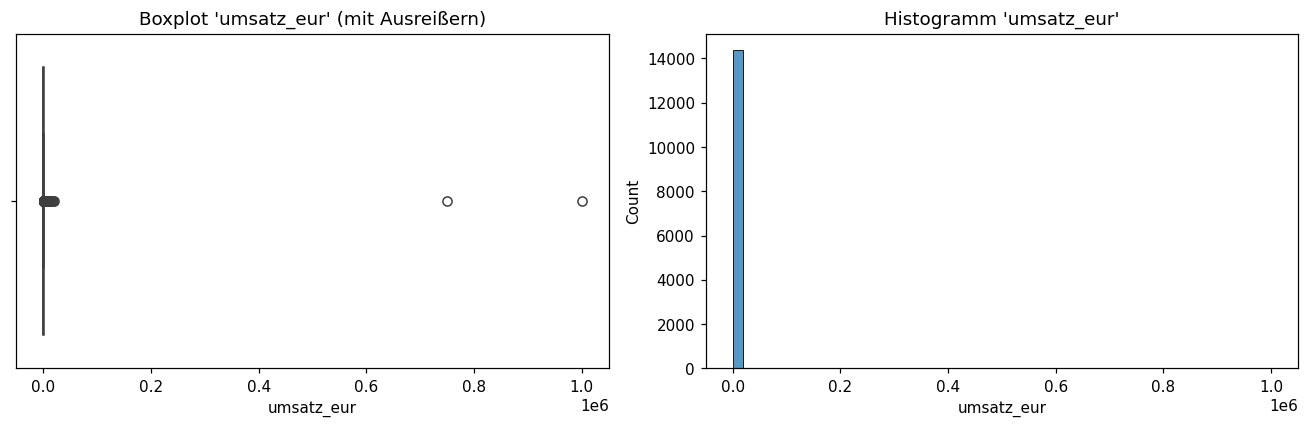

In [35]:
fig, achsen = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_verkaufe_clean["umsatz_eur"], ax=achsen[0])
achsen[0].set_title("Boxplot 'umsatz_eur' (mit Ausreißern)")
sns.histplot(df_verkaufe_clean["umsatz_eur"], bins=50, ax=achsen[1])
achsen[1].set_title("Histogramm 'umsatz_eur'")
plt.tight_layout()
plt.show()

Sowohl Boxplot als auch Histogramm werden durch einzelne extreme
Werte so stark gestaucht, dass die eigentliche Verteilung (der große
Rest der Daten liegt nahe 0) kaum noch erkennbar ist – ein klares
Anzeichen für Ausreißer.

### 4.2 Statistische Übersicht

In [36]:
df_verkaufe_clean["umsatz_eur"].describe()

,umsatz_eur
count,14400.00
mean,638.59
std,10453.46
min,-150.00
25%,70.12
50%,202.78
75%,568.28
max,999999.00


### 4.3 Extremwerte konkret ansehen

In [37]:
print("Die 5 hoechsten Werte:")
print(df_verkaufe_clean.nlargest(5, "umsatz_eur")[["produkt_id", "monat", "umsatz_eur"]])
print("\nDie 5 niedrigsten Werte:")
print(df_verkaufe_clean.nsmallest(5, "umsatz_eur")[["produkt_id", "monat", "umsatz_eur"]])

Die 5 hoechsten Werte:
      produkt_id      monat  umsatz_eur
11683    PR-0486 2025-08-01   999999.00
5679     PR-0236 2025-04-01   750000.00
9366     PR-0390 2024-07-01    20617.85
9377     PR-0390 2025-06-01    17729.43
11322    PR-0471 2025-07-01    16855.05

Die 5 niedrigsten Werte:
      produkt_id      monat  umsatz_eur
13086    PR-0545 2024-07-01     -150.00
8018     PR-0334 2024-03-01       -1.00
9373     PR-0390 2025-02-01        0.00
6311     PR-0262 2025-12-01        1.63
6301     PR-0262 2025-02-01        1.71


**Beobachtung:** Die höchsten Werte springen um mehrere
Größenordnungen gegenüber dem Rest nach oben (Platzhalter-Muster wie
`999.999` oder `750.000`), und es gibt negative Werte – ein negativer
Umsatz ist fachlich nicht möglich. Als Nächstes bestimmen wir eine
konkrete Schwelle und zählen, wie viele Zeilen betroffen sind.

### 4.4 Kreuzvalidierung über `vormonat_umsatz_eur`

Eine feste Schwelle (z. B. "> 100.000 oder < 0") findet nur Werte, die
*offensichtlich* unplausibel sind – ein fehlerhafter Wert, der zufällig
in einem plausiblen Bereich landet (wie das `0,00 €` bei `PR-0390`
oben), würde so nicht erkannt.

Da `vormonat_umsatz_eur` laut Datenbeschreibung unabhängig von
`umsatz_eur` aus dem jeweiligen Vormonat übernommen wird, muss für ein
und dasselbe Produkt gelten: **`umsatz_eur` in Monat M ==
`vormonat_umsatz_eur` in Monat M+1**. Dafür wird zuerst nach
`produkt_id` gefiltert/gruppiert und chronologisch sortiert (`monat`
aufsteigend, `jahr` aufsteigend) – erst dann steht in der Folgezeile
tatsächlich der nächste Monat desselben Produkts.

In [38]:
df_verkaufe_clean = df_verkaufe_clean.sort_values(
    ["produkt_id", "monat", "jahr"]
).reset_index(drop=True)

df_verkaufe_clean["vormonat_umsatz_folgezeile_eur"] = (
    df_verkaufe_clean.groupby("produkt_id")["vormonat_umsatz_eur"].shift(-1)
)

df_verkaufe_clean[["produkt_id", "monat", "umsatz_eur", "vormonat_umsatz_folgezeile_eur"]].head(6)

,produkt_id,monat,umsatz_eur,vormonat_umsatz_folgezeile_eur
0,PR-0000,2024-01-01,6.12,6.12
1,PR-0000,2024-02-01,13.64,13.64
2,PR-0000,2024-03-01,16.75,16.75
3,PR-0000,2024-04-01,22.68,22.68
4,PR-0000,2024-05-01,11.98,11.98
5,PR-0000,2024-06-01,9.44,9.44


**Abgleich:** stimmen `umsatz_eur` und `vormonat_umsatz_folgezeile_eur` überein?

In [39]:
vergleichbar = (
    df_verkaufe_clean["vormonat_umsatz_folgezeile_eur"].notna()
    & df_verkaufe_clean["umsatz_eur"].notna()
)
abweichung = vergleichbar & (
    df_verkaufe_clean["vormonat_umsatz_folgezeile_eur"].round(2)
    != df_verkaufe_clean["umsatz_eur"].round(2)
)

print(f"Vergleichbare Zeilen: {vergleichbar.sum()}")
print(f"Uebereinstimmend: {(~abweichung[vergleichbar]).sum()} "
      f"({(~abweichung[vergleichbar]).mean():.4%})")
print(f"Abweichend (= Datenfehler): {abweichung.sum()}")

df_verkaufe_clean.loc[
    abweichung,
    ["produkt_id", "monat", "umsatz_eur", "vormonat_umsatz_folgezeile_eur"],
]

Vergleichbare Zeilen: 13800
Uebereinstimmend: 13795 (99.9638%)
Abweichend (= Datenfehler): 5


,produkt_id,monat,umsatz_eur,vormonat_umsatz_folgezeile_eur
5679,PR-0236,2025-04-01,750000.00,396.94
8018,PR-0334,2024-03-01,-1.00,349.92
9373,PR-0390,2025-02-01,0.00,2797.05
11683,PR-0486,2025-08-01,999999.00,33.49
13086,PR-0545,2024-07-01,-150.00,10.64


### 4.5 `umsatz_eur` in den abweichenden Zeilen korrigieren

Der wahre Wert ist über die Kreuzvalidierung bereits exakt bekannt
(`vormonat_umsatz_folgezeile_eur`) – das ist eine **Rekonstruktion**,
keine Schätzung. Ein neues Flag `umsatz_korrigiert` macht transparent,
welche 5 Zeilen nicht dem Original-Export entsprechen. Die
Hilfsspalte `vormonat_umsatz_folgezeile_eur` wird danach wieder
entfernt, da ihre Information jetzt in `umsatz_eur` steckt.

In [40]:
df_verkaufe_clean["umsatz_korrigiert"] = abweichung.astype(int)
df_verkaufe_clean.loc[abweichung, "umsatz_eur"] = (
    df_verkaufe_clean.loc[abweichung, "vormonat_umsatz_folgezeile_eur"].round(2)
)
df_verkaufe_clean = df_verkaufe_clean.drop(columns=["vormonat_umsatz_folgezeile_eur"])

print(f"Korrigierte Werte (umsatz_korrigiert == 1): {df_verkaufe_clean['umsatz_korrigiert'].sum()}")
df_verkaufe_clean.loc[
    df_verkaufe_clean["umsatz_korrigiert"] == 1,
    ["produkt_id", "monat", "umsatz_eur", "umsatz_korrigiert"],
]

Korrigierte Werte (umsatz_korrigiert == 1): 5


,produkt_id,monat,umsatz_eur,umsatz_korrigiert
5679,PR-0236,2025-04-01,396.94,1
8018,PR-0334,2024-03-01,349.92,1
9373,PR-0390,2025-02-01,2797.05,1
11683,PR-0486,2025-08-01,33.49,1
13086,PR-0545,2024-07-01,10.64,1


**Kontrolle:** keine unplausiblen Extremwerte mehr, 0 fehlende Werte in `umsatz_eur`?

In [41]:
print(df_verkaufe_clean["umsatz_eur"].describe())
print(f"\nFehlende Werte in 'umsatz_eur': {df_verkaufe_clean['umsatz_eur'].isna().sum()} (erwartet 0)")

count   14400.00
mean      517.33
std       949.38
min         1.63
25%        70.19
50%       202.82
75%       568.00
max     20617.85
Name: umsatz_eur, dtype: float64

Fehlende Werte in 'umsatz_eur': 0 (erwartet 0)


## 5 Verbleibende Spalten bereinigen

### 5.1 `lagerbestand` bereinigen

Suchen/zählen (siehe 2.4): 288 Zeilen mit Text-Zusatz `"Stueck"`.
Bereinigen: Zusatz entfernen, in `int` umwandeln.

In [42]:
lagerbestand_mit_text = df_verkaufe_clean["lagerbestand"].astype(str).str.contains("[A-Za-z]")
print(f"Zeilen mit Text-Zusatz: {lagerbestand_mit_text.sum()} von {len(df_verkaufe_clean)}")

df_verkaufe_clean["lagerbestand"] = (
    df_verkaufe_clean["lagerbestand"].astype(str)
    .str.replace("Stueck", "", regex=False)
    .str.strip()
    .astype(int)
)
print(f"Datentyp jetzt: {df_verkaufe_clean['lagerbestand'].dtype}")
df_verkaufe_clean["lagerbestand"].describe()

Zeilen mit Text-Zusatz: 288 von 14400
Datentyp jetzt: int64


,lagerbestand
count,14400.00
mean,74.40
std,43.55
min,1.00
25%,42.00
50%,66.00
75%,97.00
max,441.00


**Kontrolle:** kein Text-Zusatz mehr übrig?

In [43]:
noch_text = df_verkaufe_clean["lagerbestand"].astype(str).str.contains("[A-Za-z]").sum()
print(f"Verbleibende Zeilen mit Text: {noch_text} (erwartet 0)")

Verbleibende Zeilen mit Text: 0 (erwartet 0)


**Ergebnis:** `lagerbestand` ist jetzt durchgehend `int`, kein Text-Zusatz mehr vorhanden.

### 5.2 `bewertungen_durchschnitt` rekonstruieren

576 fehlende Werte. Suchen: ist der Wert pro Produkt konstant? Falls
ja, ist ein fehlender Monatswert kein unbekannter Wert, sondern nur an
dieser Stelle nicht mitgeschrieben, obwohl er aus anderen Monaten
desselben Produkts exakt bekannt ist.

In [44]:
eindeutige_je_produkt = df_verkaufe_clean.groupby("produkt_id")["bewertungen_durchschnitt"].nunique()
print(f"Produkte mit genau 1 eindeutigem Wert: {(eindeutige_je_produkt == 1).sum()} "
      f"von {df_verkaufe_clean['produkt_id'].nunique()}")

Produkte mit genau 1 eindeutigem Wert: 600 von 600


**Ergebnis:** bei allen 600 Produkten ist `bewertungen_durchschnitt`
über die Monate hinweg konstant – eine fehlende Zeile ist also keine
unbekannte Bewertung, sondern nur eine Lücke im Export.

**Bereinigen:** statt einer Schätzung (Mean/Median) wird der Wert
je `produkt_id` per Forward-/Backward-Fill rekonstruiert. Flag
`bewertungen_ergaenzt` markiert die betroffenen Zeilen.

In [45]:
df_verkaufe_clean["bewertungen_ergaenzt"] = df_verkaufe_clean["bewertungen_durchschnitt"].isna().astype(int)
df_verkaufe_clean["bewertungen_durchschnitt"] = (
    df_verkaufe_clean.groupby("produkt_id")["bewertungen_durchschnitt"].transform(lambda s: s.ffill().bfill())
)

print(f"'bewertungen_ergaenzt' == 1: {df_verkaufe_clean['bewertungen_ergaenzt'].sum()} (erwartet 576)")
print(f"Verbleibend fehlend: {df_verkaufe_clean['bewertungen_durchschnitt'].isna().sum()} (erwartet 0)")

'bewertungen_ergaenzt' == 1: 576 (erwartet 576)
Verbleibend fehlend: 0 (erwartet 0)


### 5.3 `marketingbudget_eur` auffüllen

433 fehlende Werte. Suchen: hängt das Fehlen mit `kategorie` oder
`kampagne_aktiv` zusammen?

In [46]:
fehlquote_kampagne = df_verkaufe_clean.groupby("kampagne_aktiv")["marketingbudget_eur"].apply(lambda s: s.isna().mean())
print("Fehlquote je 'kampagne_aktiv':")
print(fehlquote_kampagne)

median_je_kategorie = df_verkaufe_clean.groupby("kategorie")["marketingbudget_eur"].median()
print("\nMedian je Kategorie:")
print(median_je_kategorie.round(2))

Fehlquote je 'kampagne_aktiv':
kampagne_aktiv
0   0.03
1   0.03
Name: marketingbudget_eur, dtype: float64

Median je Kategorie:
kategorie
Bewaesserung   88.53
Duengemittel   90.72
Pflanzen       87.79
Saatgut        85.58
Toepfe         88.08
Werkzeuge      89.11
Name: marketingbudget_eur, dtype: float64


**Bereinigen:** kein erkennbarer Zusammenhang mit `kampagne_aktiv`
(Fehlquote in beiden Gruppen ähnlich), Mediane je Kategorie liegen eng
beieinander – daher Median je Kategorie zum Auffüllen (robuster als
Mittelwert bei rechtsschiefer Verteilung). Flag
`marketingbudget_geschaetzt` markiert die betroffenen Zeilen.

In [47]:
df_verkaufe_clean["marketingbudget_geschaetzt"] = df_verkaufe_clean["marketingbudget_eur"].isna().astype(int)
df_verkaufe_clean["marketingbudget_eur"] = df_verkaufe_clean["marketingbudget_eur"].fillna(
    df_verkaufe_clean["kategorie"].map(median_je_kategorie)
)

print(f"'marketingbudget_geschaetzt' == 1: {df_verkaufe_clean['marketingbudget_geschaetzt'].sum()} "
      f"(433 im Rohdatensatz, davon 1 Zeile als Duplikat entfernt -> erwartet 432)")
print(f"Verbleibend fehlend: {df_verkaufe_clean['marketingbudget_eur'].isna().sum()} (erwartet 0)")

'marketingbudget_geschaetzt' == 1: 432 (433 im Rohdatensatz, davon 1 Zeile als Duplikat entfernt -> erwartet 432)
Verbleibend fehlend: 0 (erwartet 0)


### 5.4 Flags für die bereits korrekten strukturellen NaN-Spalten

`vorjahr_monat_umsatz_eur` und `vormonat_umsatz_eur` stimmen laut 3.7
bereits exakt mit der Logik überein – an den Werten selbst ändert sich
nichts, es fehlen nur noch die Flags (analog zu
`hat_3_monats_durchschnitt`), damit Modelle ohne `NaN`-Unterstützung
diese Information trotzdem nutzen können.

In [48]:
df_verkaufe_clean["hat_vorjahreswert"] = df_verkaufe_clean["vorjahr_monat_umsatz_eur"].notna().astype(int)
df_verkaufe_clean["neues_produkt"] = df_verkaufe_clean["vormonat_umsatz_eur"].isna().astype(int)

print(f"'hat_vorjahreswert' == 0: {(df_verkaufe_clean['hat_vorjahreswert'] == 0).sum()} (erwartet 7.200)")
print(f"'neues_produkt' == 1: {df_verkaufe_clean['neues_produkt'].sum()} (erwartet 600)")

'hat_vorjahreswert' == 0: 7200 (erwartet 7.200)
'neues_produkt' == 1: 600 (erwartet 600)


**Ergebnis:** beide Flags treffen exakt auf die in 3.7 hergeleiteten
Zeilenzahlen (7.200 bzw. 600) – die strukturelle Logik und die Flags
stimmen überein. Damit sind alle Spalten aus dem Rohdatensatz bereinigt
oder mit einem erklärenden Flag versehen.

## 6 Abschluss

### 6.1 Finale Spaltenreihenfolge

Jedes Flag direkt neben seiner Quellspalte.

In [49]:
spalten_reihenfolge = [
    "produkt_id", "kategorie", "hersteller", "monat", "jahr", "monat_idx",
    "preis_eur", "wettbewerber_preis_eur",
    "marketingbudget_eur", "marketingbudget_geschaetzt",
    "kampagne_aktiv", "lagerbestand",
    "bewertungen_durchschnitt", "bewertungen_ergaenzt", "bewertungen_anzahl",
    "vormonat_umsatz_eur", "neues_produkt",
    "letzte_3_monate_umsatz_eur_avg", "hat_3_monats_durchschnitt",
    "vorjahr_monat_umsatz_eur", "hat_vorjahreswert",
    "umsatz_eur", "umsatz_korrigiert",
]
df_verkaufe_clean = df_verkaufe_clean[spalten_reihenfolge]
print(f"Datensatz jetzt: {df_verkaufe_clean.shape[0]} Zeilen, {df_verkaufe_clean.shape[1]} Spalten.")
verbleibend = df_verkaufe_clean.isna().sum()
verbleibend[verbleibend > 0]

Datensatz jetzt: 14400 Zeilen, 23 Spalten.


,0
vormonat_umsatz_eur,600
letzte_3_monate_umsatz_eur_avg,1800
vorjahr_monat_umsatz_eur,7200


**Ergebnis:** 23 Spalten in der finalen Reihenfolge, keine Spalte
mit unerwarteten (nicht durch ein Flag erklärten) Fehlwerten mehr.

### 6.2 Als CSV speichern

In [50]:
os.makedirs("../data/interim", exist_ok=True)
OUT_PATH = "../data/interim/verkaufe_clean.csv"
df_verkaufe_clean.to_csv(OUT_PATH, index=False, date_format="%Y-%m-%d")

print(f"Gespeichert unter: {OUT_PATH}")
print(f"Finale Form: {df_verkaufe_clean.shape[0]} Zeilen, {df_verkaufe_clean.shape[1]} Spalten "
      f"(Rohdatensatz: {df_verkaufe_raw.shape[0]} Zeilen, {df_verkaufe_raw.shape[1]} Spalten).")

Gespeichert unter: ../data/interim/verkaufe_clean.csv
Finale Form: 14400 Zeilen, 23 Spalten (Rohdatensatz: 14430 Zeilen, 16 Spalten).


## Zusammenfassung

Der Rohdatensatz (14.430 Zeilen × 16 Spalten) sah auf den ersten Blick
brauchbar aus – vollständig befüllt, plausible Werte. Erst der
Statistik-Check in Abschnitt 2 und die anschließende Bereinigung haben
gezeigt, dass praktisch jede Spalte ihr eigenes kleines Problem hatte.
Insgesamt wurden acht eigenständige Datenfehler gefunden. Die
Spaltennamen selbst blieben dabei bewusst unverändert die technischen
`snake_case`-Namen aus `verkaufe.csv` (klein geschrieben, nur `_` als
Sonderzeichen) – direkt SQL-/datenbanktauglich, ohne einen separaten
Übersetzungsschritt.

1. **30 vollständige Duplikate** – ganze Zeilen, die identisch ein
   zweites Mal im Export steckten, statt nur einmal pro Produkt und
   Monat vorzukommen.
2. **`kategorie` in 24 statt 6 Schreibweisen** – dieselbe fachliche
   Kategorie wurde je nach Zeile groß, klein, mit und ohne Umlaute oder
   als Abkürzung geschrieben (`Saatgut`/`saatgut`/`SAAT`).
3. **`monat` in drei verschiedenen Datumsformaten** – `MM.YYYY`,
   `YYYY-MM` und `MM/YYYY` standen nebeneinander in derselben Spalte.
4. **`preis_eur` als Textfeld** – Werte wie `"1,50 €"` (Text mit
   Euro-Zeichen und Komma) und `1.5` (reine Zahl) gemischt, obwohl der
   Preis pro Produkt konstant sein sollte.
5. **`lagerbestand` mit Text-Zusatz** – 288 Zeilen enthielten
   zusätzlich das Wort „Stueck“ statt einer reinen Zahl.
6. **`letzte_3_monate_umsatz_eur_avg` fälschlich befüllt** – in 1.799
   Zeilen stand ein Wert, obwohl zu diesem Zeitpunkt (Monat 1–3 des
   Jahres 2024) noch gar keine drei vollständigen Vormonate existieren
   konnten. Ein systematischer Fehler im Export, keine Einzelfälle.
7. **5 unplausible Werte in `umsatz_eur`** – Platzhalter-artige Extremwerte
   und ein falsch übernommener Nullwert, die erst durch den Abgleich mit
   `vormonat_umsatz_eur` der jeweiligen Folgezeile als Fehler auffielen
   und exakt rekonstruiert werden konnten.
8. **Echte, musterlose Fehlwerte** – 432 fehlende `marketingbudget_eur`-
   und 576 fehlende `bewertungen_durchschnitt`-Werte, die nicht strukturell
   erklärbar waren, sondern schlicht Lücken im Datenexport.

Für jeden dieser acht Fehler wurde zuerst gesucht und gezählt, wie viele
Zeilen betroffen sind, bevor überhaupt korrigiert wurde – und jede
Korrektur ist über ein eigenes Flag nachvollziehbar (`umsatz_korrigiert`,
`hat_3_monats_durchschnitt`, `bewertungen_ergaenzt`,
`marketingbudget_geschaetzt`, `hat_vorjahreswert`, `neues_produkt`). Wo
der wahre Wert exakt bekannt war (Duplikate, Umsatz-Kreuzvalidierung,
`bewertungen_durchschnitt`), wurde er rekonstruiert statt geschätzt; nur beim
Marketingbudget kam mangels Alternative der Median je Kategorie zum
Einsatz.

Ergebnis: `data/interim/verkaufe_clean.csv`, 14.400 Zeilen × 23 Spalten,
0 verbleibende unerklärte Fehlwerte, durchgehend `snake_case`-Spaltennamen.
Die Rohdatei `verkaufe.csv` selbst wurde zu keinem Zeitpunkt verändert.